### M3234 Артемьев Марк

$$ 
f(x) = [x], E = [0, 4], F(x) = 
\begin{cases}
0, x \le 1; \\
x, 1 < x \le 2; \\
3, x > 2.
\end{cases}
$$

In [4]:
from math import ceil
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

In [ ]:
def f(x):
    return int(x)

def f_n(x, n):
    for x0 in [1, 2, 3, 4]:
        # из-за неточности вычислений пк
        if abs(x - x0) < 1e-7:
            return int(round(x)) - 1/n
    return int(x)

def F(x):
    if x <= 1:
        return 0
    if 1 < x <= 2:
        return x
    return 3

In [ ]:
# ставит точку на график
def dot(x, y, place, style="full"):
    place.plot(x, y, 'o', fillstyle=style, color='red', markersize=6)


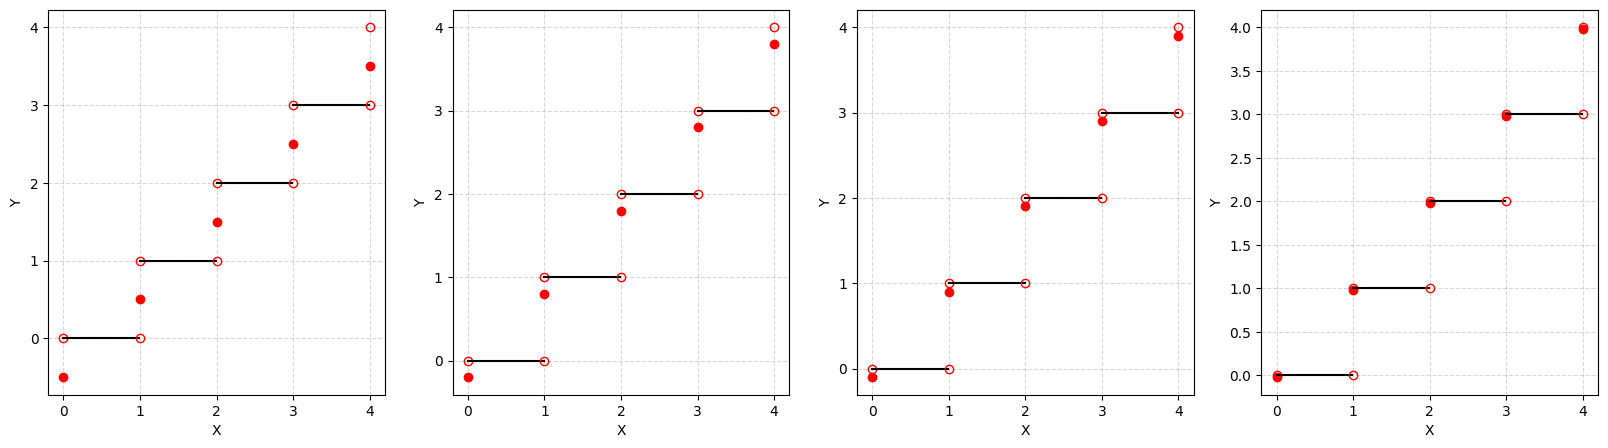

In [ ]:
N = [2, 5, 10, 50]
# плоскость с 4-мя графиками
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i in range(len(N)):
    n = N[i]
    ax = axes[i]
    dot(0, 0 - 1/n, ax)
    dot(0, 0, ax, 'none')
    for x_0 in range(0, 4):
        X = np.linspace(x_0, x_0 + 1, 100)[:-1]
        # проще использовать np.floor чем разделять функцию 
        # на области непрерывности и чертить график по отдельности 
        Y = np.floor(X)
        ax.plot(X, Y, color="black")

        dot(x_0 + 1, x_0, ax, 'none')
        dot(x_0 + 1, x_0 + 1 - 1/n, ax)
        dot(x_0 + 1, x_0 + 1, ax, 'none')

    ax.set_xlabel('X', fontsize=10)
    ax.set_ylabel('Y', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)


In [ ]:
steps = 1000
def integral(f, n, type="L"):
    a, b = [0, 4]
    dx = (b - a) / steps
    ssum = 0

    # для меры Лебега
    if type == "L":
        for i in range(steps):
            x = a + (i + 0.5) * dx
            ssum += f(x, n) * dx
        return ssum

    # мера Лебега-Стилтьеса
    for i in range(steps):
        x_cur = a + i * dx
        x_next = a + (i + 1) * dx

        res_f = f(x_cur, n)
        delta_F = F(x_next) - F(x_cur)
        
        ssum += res_f * delta_F
        
    return ssum

In [18]:
N = [1000, 10000, 100000]
for n in N:
    I = integral(f_n, n, "L")
    print(I)


5.999999999999931
5.999999999999931
5.999999999999931


Интеграл Лебега от $ f_n(x) $ очень близок к интегралу Лебега $ f(x) $ (6), так как вычисления на пк не идеально точны и шаг не близок к бесконечности. Теорема выполняется.

In [19]:
for n in N:
    I = integral(f_n, n, "LS")
    print(I)


3.997996
3.9997996000000002
3.99997996


Значение интеграла Лебега-Стилтьеса $ f_n(x) $ стремится к значению интеграла $ f(x) $ (4) при $ n \rightarrow \infty $. Теорема выполняется.

Численные вычисления очень близки к аналитическим, увеличение значения $ n $ и шага $ steps $ приблизится к точному результату. Условия теоремы Бепо Леви были соблюдены и результы получились соответствующие.